# Chronos Zero-Shot Forecasting — Wirkung der Kontextfenster-Länge

Diese Demo zeigt, wie stark die **Länge des Kontextfensters** (also wie viele
historische Datenpunkte man dem Modell mitgibt) die Prognosequalität eines
Zeitreihen-Foundation-Models (**Chronos**, Amazon Science) beeinflusst.

Datensatz: das Klassiker-Beispiel **AirPassengers** (monatliche
Fluggastzahlen, 1949–1960).

## Inhalt
1. Setup & Installation
2. Daten laden
3. Modell laden
4. Statischer Vergleich: voller vs. kurzer Kontext
5. **Interaktive Demo** — Kontextfenster, Prognosehorizont und
   Konfidenzintervall live per Schieberegler anpassen

> 💡 **Hinweis:** Jede Slider-Änderung löst eine neue Chronos-Inferenz aus.
> Auf der CPU dauert das je nach Einstellung ca. 1–5 Sekunden — kurz warten,
> bis der Plot sich aktualisiert.

---


## 1. Setup & Installation

Falls die folgenden Pakete noch nicht installiert sind, die nächste Zelle
entkommentieren und einmalig ausführen (z. B. in Google Colab).


In [ ]:
# %pip install git+https://github.com/amazon-science/chronos-forecasting.git
# %pip install torch pandas numpy matplotlib ipywidgets


In [2]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from functools import lru_cache
from chronos import ChronosPipeline

# Basis-Schriftgröße für die gesamte Abbildung (Titel, Achsen, Legende
# skalieren automatisch relativ dazu).
FONT_SIZE = 14
plt.rcParams.update({
    "font.size": FONT_SIZE,
    "axes.titlesize": FONT_SIZE + 2,
    "axes.labelsize": FONT_SIZE,
    "xtick.labelsize": FONT_SIZE - 1,
    "ytick.labelsize": FONT_SIZE - 1,
    "legend.fontsize": FONT_SIZE - 1,
})


## 2. Daten laden

Wir laden den AirPassengers-Datensatz direkt von GitHub. `values` enthält
die reine Zeitreihe (Passagierzahlen), `dates` die dazugehörigen Monate.


In [3]:
DATA_URL = (
    "https://raw.githubusercontent.com/AileenNielsen/"
    "TimeSeriesAnalysisWithPython/master/data/AirPassengers.csv"
)

df = pd.read_csv(DATA_URL)
values = df["#Passengers"].astype(float).values
dates = pd.to_datetime(df["Month"])

print(f"Datensatz: {len(values)} Monate, "
      f"von {dates.iloc[0].date()} bis {dates.iloc[-1].date()}")


Datensatz: 144 Monate, von 1949-01-01 bis 1960-12-01


## 3. Modell laden

`amazon/chronos-t5-small` ist die kleinste Chronos-Variante — schnell genug
für eine interaktive Demo auf der CPU. Für bessere Prognosequalität (auf
Kosten der Geschwindigkeit) können auch `chronos-t5-base` oder
`chronos-t5-large` verwendet werden.


In [4]:
MODEL_NAME = "amazon/chronos-t5-small"
DEVICE = "cpu"  # "cuda" falls eine GPU verfügbar ist

print(f"Lade Chronos-Modell: {MODEL_NAME} ...")
pipeline = ChronosPipeline.from_pretrained(
    MODEL_NAME,
    device_map=DEVICE,
    torch_dtype=torch.float32,
)
print("Modell geladen.")


Lade Chronos-Modell: amazon/chronos-t5-small ...


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

Modell geladen.


## 4. Statischer Vergleich: voller vs. kurzer Kontext

Bevor wir zur interaktiven Version kommen, bauen wir uns wiederverwendbare
Hilfsfunktionen und reproduzieren damit den ursprünglichen Vergleich aus
zwei Panels (voller Kontext vs. nur die letzten 36 Monate).

**`get_test_split`** legt fest, welcher Teil der Zeitreihe als Testzeitraum
(Ground Truth zum Vergleich mit der Prognose) zurückgehalten wird.

**`run_forecast`** berechnet für ein gegebenes Kontextfenster und einen
gegebenen Prognosehorizont die Chronos-Vorhersage. Das Ergebnis wird
gecacht (`lru_cache`), damit identische Einstellungen in der interaktiven
Demo nicht erneut berechnet werden müssen.

**`quantiles_for_interval`** wandelt eine gewünschte Konfidenzintervall-Breite
(z. B. `0.8` für ein 80%-Intervall) in die passenden unteren/oberen Quantile um.

**`plot_panel`** zeichnet ein einzelnes Forecast-Panel und wird sowohl vom
statischen Vergleich als auch von der interaktiven Demo genutzt.


In [5]:
def get_test_split(prediction_length):
    """Bestimmt den Split zwischen verfügbarer Historie und Testzeitraum.

    Die letzten `prediction_length` Monate werden als Ground Truth
    zurückgehalten und später mit der Prognose verglichen.
    """
    context_len_full = len(values) - prediction_length
    actual_future = values[context_len_full:]
    forecast_index = dates.iloc[context_len_full:]
    cutoff_date = dates.iloc[context_len_full]
    return context_len_full, actual_future, forecast_index, cutoff_date


@lru_cache(maxsize=64)
def run_forecast(context_months, prediction_length, num_samples):
    """Berechnet einen Chronos-Forecast für ein gegebenes Kontextfenster.

    Parameters
    ----------
    context_months : int oder None
        Anzahl der Monate vor dem Cutoff, die als Kontext genutzt werden.
        None = gesamte verfügbare Historie.
    prediction_length : int
        Anzahl der Monate, die vorhergesagt werden (= Testzeitraum).
    num_samples : int
        Anzahl der vom Modell gezogenen Trajektorien (mehr = glattere
        Quantile, aber langsamer).

    Returns
    -------
    dict mit allen für's Plotten benötigten Größen.
    """
    context_len_full, actual_future, forecast_index, cutoff_date = get_test_split(prediction_length)

    if context_months is None:
        ctx_start = 0
    else:
        ctx_start = max(0, context_len_full - context_months)

    context = values[ctx_start:context_len_full]

    forecast = pipeline.predict(
        torch.tensor(context),
        prediction_length=prediction_length,
        num_samples=num_samples,
    )

    return {
        "ctx_start": ctx_start,
        "context_len_full": context_len_full,
        "forecast_raw": forecast[0].numpy(),
        "actual_future": actual_future,
        "forecast_index": forecast_index,
        "cutoff_date": cutoff_date,
    }


def quantiles_for_interval(forecast_raw, interval_width):
    """Wandelt eine Konfidenzintervall-Breite (z. B. 0.8 = 80%) in die
    passenden unteren/oberen Quantile um."""
    lower_q = (1 - interval_width) / 2
    upper_q = 1 - lower_q
    low, median, high = np.quantile(forecast_raw, [lower_q, 0.5, upper_q], axis=0)
    return low, median, high


def plot_panel(ax, result, interval_width, title):
    """Zeichnet ein einzelnes Forecast-Panel."""
    ctx_start = result["ctx_start"]
    context_len_full = result["context_len_full"]
    forecast_index = result["forecast_index"]
    actual_future = result["actual_future"]
    cutoff_date = result["cutoff_date"]

    low, median, high = quantiles_for_interval(result["forecast_raw"], interval_width)

    # Historie VOR Kontextbeginn: gestrichelt, da vom Modell nicht gesehen.
    # (+1 Punkt Überlappung, damit die Linie nahtlos in den Kontext übergeht)
    if ctx_start > 0:
        ax.plot(
            dates.iloc[: ctx_start + 1], values[: ctx_start + 1],
            color="royalblue", linewidth=1.5, linestyle="--", alpha=0.6,
            label="Ground Truth (nicht im Kontext)",
        )

    # Genutzter Kontext: durchgezogen
    ax.plot(
        dates.iloc[ctx_start:context_len_full + 1], values[ctx_start:context_len_full + 1],
        color="royalblue", linewidth=2, label="Ground Truth (Kontext)",
    )
    ax.plot(forecast_index, median, color="tomato", linewidth=2, label="Median Forecast")
    ax.fill_between(
        forecast_index, low, high, color="tomato", alpha=0.3,
        label=f"{int(round(interval_width * 100))}% Interval",
    )

    # Echte Testdaten im Prognosezeitraum -- gruen, damit der Vergleich
    # zwischen Vorhersage und Realitaet direkt sichtbar ist.
    ax.plot(
        forecast_index, actual_future,
        color="seagreen", linewidth=2.2, label="Ground Truth (Test)", zorder=5,
    )

    ax.axvline(cutoff_date, color="gray", linestyle="--", linewidth=1)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.grid(alpha=0.3)
    ax.legend(loc="upper left", frameon=True, fontsize=9)
    # Beide Panels zeigen die komplette Zeitachse, unabhängig vom Kontextfenster.
    ax.set_xlim(dates.iloc[0], dates.iloc[-1])


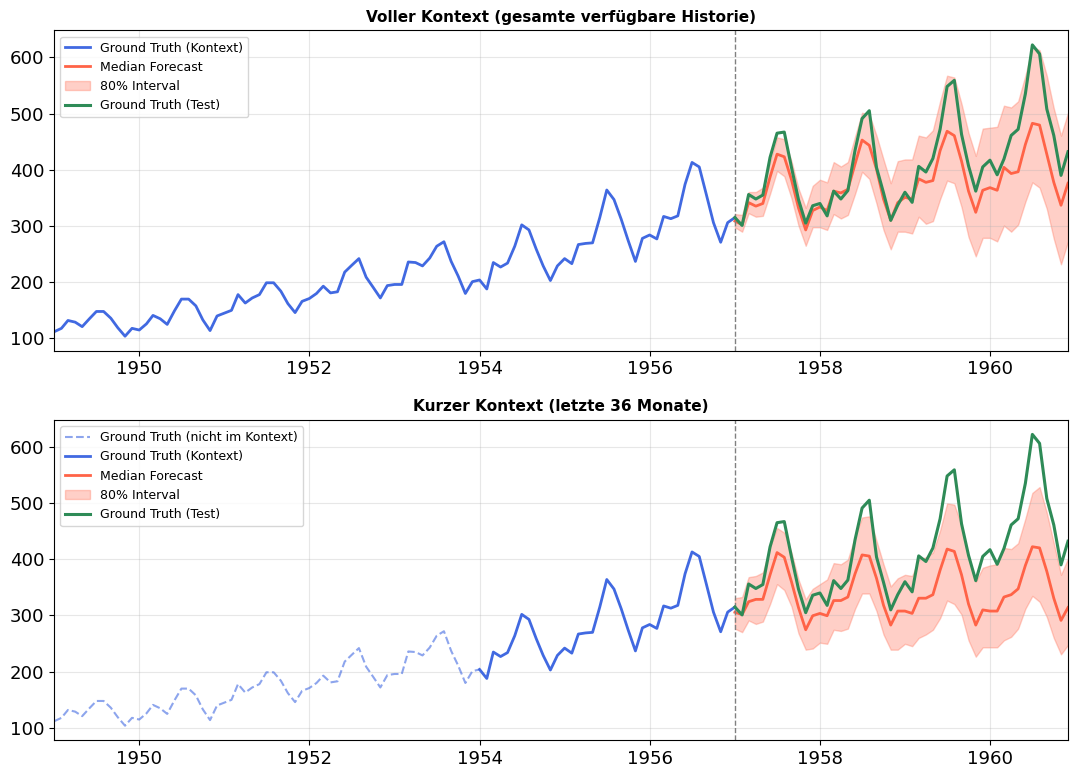

In [6]:
CONTEXT_CONFIGS = [
    {"label": "Voller Kontext (gesamte verfügbare Historie)", "context_months": None},
    {"label": "Kurzer Kontext (letzte 36 Monate)", "context_months": 36},
]
PREDICTION_LENGTH = 48
INTERVAL_WIDTH = 0.8
NUM_SAMPLES = 201
OUTPUT_FILE = "chronos_context_length_comparison.png"

fig, axes = plt.subplots(len(CONTEXT_CONFIGS), 1, figsize=(11, 4 * len(CONTEXT_CONFIGS)))
if len(CONTEXT_CONFIGS) == 1:
    axes = [axes]

for ax, cfg in zip(axes, CONTEXT_CONFIGS):
    result = run_forecast(cfg["context_months"], PREDICTION_LENGTH, NUM_SAMPLES)
    plot_panel(ax, result, INTERVAL_WIDTH, cfg["label"])

plt.tight_layout()
plt.show()


## 5. Interaktive Demo

Mit den Schiebereglern lassen sich live anpassen:

- **Kontext (Monate)** — wie viele historische Monate das Modell zu sehen
  bekommt (bzw. Checkbox für den kompletten verfügbaren Kontext)
- **Prognosehorizont (Monate)** — wie weit in die Zukunft vorhergesagt wird
- **Konfidenzintervall** — die Breite des grau-orangen Unsicherheitsbands
  (z. B. 80% = 10.–90. Perzentil)
- **Sample-Anzahl** — mehr Samples → glattere Quantile, aber langsamer

Regler nutzen `continuous_update=False`, d. h. die Neuberechnung startet
erst, wenn man den Regler loslässt.


In [ ]:
import ipywidgets as widgets
from IPython.display import display

_slider_style = {"description_width": "170px"}
_slider_layout = widgets.Layout(width="480px")

context_slider = widgets.IntSlider(
    value=36, min=6, max=len(values) - 12, step=6,
    description="Kontext (Monate):", continuous_update=False,
    style=_slider_style, layout=_slider_layout,
)
full_context_checkbox = widgets.Checkbox(
    value=False, description="stattdessen vollen Kontext nutzen",
)
prediction_slider = widgets.IntSlider(
    value=24, min=6, max=48, step=6,
    description="Prognosehorizont (Monate):", continuous_update=False,
    style=_slider_style, layout=_slider_layout,
)
interval_slider = widgets.FloatSlider(
    value=0.8, min=0.5, max=0.95, step=0.05,
    description="Konfidenzintervall:", continuous_update=False,
    readout_format=".0%",
    style=_slider_style, layout=_slider_layout,
)
samples_slider = widgets.IntSlider(
    value=201, min=20, max=400, step=20,
    description="Sample-Anzahl:", continuous_update=False,
    style=_slider_style, layout=_slider_layout,
)


def update_plot(context_months, use_full_context, prediction_length, interval_width, num_samples):
    ctx = None if use_full_context else context_months

    result = run_forecast(ctx, prediction_length, num_samples)

    label = "Voller Kontext" if ctx is None else f"Kontext: {ctx} Monate"
    title = f"{label} · Horizont: {prediction_length} Monate"

    fig, ax = plt.subplots(figsize=(11, 4.5))
    plot_panel(ax, result, interval_width, title)
    plt.tight_layout()
    plt.show()


interactive_demo = widgets.interactive(
    update_plot,
    context_months=context_slider,
    use_full_context=full_context_checkbox,
    prediction_length=prediction_slider,
    interval_width=interval_slider,
    num_samples=samples_slider,
)

display(interactive_demo)


interactive(children=(IntSlider(value=36, continuous_update=False, description='Kontext (Monate):', layout=Lay…

---
## Nächste Schritte

Zum Weiterexperimentieren:

- **Anderes Modell:** `MODEL_NAME` auf `amazon/chronos-t5-base` oder
  `amazon/chronos-t5-large` ändern (langsamer, aber i. d. R. genauer).
- **Anderer Datensatz:** eigene CSV mit einer Spalte für Werte und einer für
  Zeitstempel laden und `values`/`dates` entsprechend anpassen.
- **Kovariaten:** Chronos-2 unterstützt zusätzliche externe Einflussgrößen
  (z. B. Promotionen, Wetter) — siehe die
  [Chronos-Dokumentation](https://github.com/amazon-science/chronos-forecasting).
- **Sample-Anzahl vs. Geschwindigkeit:** mit dem Sample-Regler experimentieren,
  um den Trade-off zwischen glatten Quantilen und Rechenzeit zu spüren.

**Quelle:** Ansari et al. (2024), *Chronos: Learning the Language of Time
Series* — https://github.com/amazon-science/chronos-forecasting
